In [2]:
# Import pandas - a library that lets us work with tables of data
import pandas as pd

# Load the insurance dataset from the internet into a table called 'insurance'
insurance = pd.read_csv('https://raw.githubusercontent.com/KeithGalli/Regression-Example/master/insurance.csv')

In [3]:
# Show the first 5 rows of the dataset so we can see what it looks like
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.924
1,18.0,male,33.770,1.0,no,Southeast,1725.5523
2,28.0,male,33.000,3.0,no,southeast,$4449.462
3,33.0,male,22.705,0.0,no,northwest,$21984.47061
4,32.0,male,28.880,0.0,no,northwest,$3866.8552


In [6]:
# ---- STEP 1: DATA CLEANING ----
# Goal: fix messy data so it's consistent and ready for analysis

# Remove any rows that have missing (empty) values
insurance_filled = insurance.dropna()

# Make all region names lowercase so 'Southwest' and 'southwest' are treated the same
insurance_filled["region"] = insurance_filled["region"].str.lower()

# Map any alternate sex labels to standard 'male' / 'female'
# (in case the data had values like 'M', 'F', 'man', 'woman')
sex_map = {'woman': 'female', 'F': 'female', 'man': 'male', 'M': 'male'}
insurance_filled["sex"] = insurance_filled["sex"].replace(sex_map)

# Convert smoker column from 'yes'/'no' text to True/False (boolean)
insurance_filled["smoker"] = (insurance_filled["smoker"] == 'yes')

# Make all number columns positive (remove any accidental negative values)
# Skips text columns automatically
insurance_cleaned = insurance_filled.apply(lambda x: x.abs() if x.dtype == 'float64' or x.dtype == 'int64' else x)

# Drop any rows that might still have missing values after cleaning
insurance_cleaned = insurance_cleaned.dropna()

# Save the cleaned data to a CSV file so we don't have to redo this every time
insurance_cleaned.to_csv('cleaned_insurance_data.csv', index=False)

# Show a random sample of 10 rows to confirm the data looks good
insurance_cleaned.sample(10)

,age,sex,bmi,children,smoker,region,charges
432,42.0,male,26.900,0.0,False,southwest,$5969.723
1044,55.0,male,35.245,1.0,False,northeast,$11394.06555
1068,63.0,male,21.660,1.0,False,northwest,14349.8544
662,32.0,female,31.540,1.0,False,northeast,5148.5526
368,44.0,male,32.015,2.0,False,northwest,8116.26885
932,46.0,male,25.800,5.0,False,southwest,$10096.97
1289,44.0,male,34.320,1.0,False,southeast,7147.4728
1090,47.0,male,36.190,0.0,True,southeast,41676.0811
140,34.0,male,22.420,2.0,False,northeast,27375.90478
1330,57.0,female,25.740,2.0,False,southeast,12629.1656


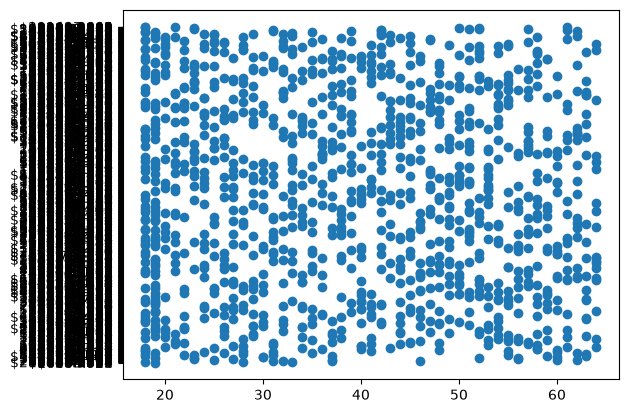

In [10]:
#2.Create a plot of the data
import matplotlib.pyplot as plt 

df = insurance_cleaned.copy()

plt.scatter(df['age'],df['charges'])